# CAMELS-GB v2 — data exploration

**CAMELS-GB v2** (Catchment Attributes and MEteorology for Large-sample Studies,
Great Britain) is a hydrological benchmark dataset from the UK Centre for Ecology
& Hydrology. It pairs **671 river catchments** with static catchment attributes,
catchment boundary polygons, and long meteorological + streamflow time series.

What is on disk (verified byte-for-byte against the EIDC catalogue):

| | |
|---|---|
| Catchments | 671 |
| Groundwater wells | 55 |
| Files | 1,436 (10.6 GiB) |
| Daily record | 1970-10-01 → 2022-09-30 (52 water years) |
| Hourly record | 1990-10-01 → 2022-10-01 |

This notebook walks the dataset end to end: inventory → attributes → geography →
climate/hydrology signatures → land cover → time series → flood-relevant extremes.

Source: [EIDC 9a46d428-958f-4ac1-86eb-94eee70c0955](https://catalogue.ceh.ac.uk/documents/9a46d428-958f-4ac1-86eb-94eee70c0955)

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Locate the project root whether this runs from the repo root or from notebooks/
ROOT = Path.cwd()
while not (ROOT / "data" / "Catchment_Attributes").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA   = ROOT / "data"
ATTR   = DATA / "Catchment_Attributes"
BOUND  = DATA / "Catchment_Boundaries"
TS     = DATA / "Catchment_Timeseries"
DAILY  = TS / "hydro-meteorological" / "daily"
HOURLY = TS / "hydro-meteorological" / "hourly"
GW     = TS / "groundwater"
CACHE  = ROOT / "cache"
CACHE.mkdir(exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("project root:", ROOT)

project root: /home/habrt/source/flood


## Plot style

Colour is assigned by the job it does, not by taste:

- **categorical** (identity) — a fixed 8-slot hue order, used in order and never cycled
- **sequential** (magnitude) — one hue, light → dark
- **diverging** (polarity) — two hues either side of a neutral grey midpoint

The categorical order below was validated for colour-vision-deficiency separation
(worst adjacent pair ΔE 9.1, target ≥ 8) and for normal-vision separation
(worst adjacent ΔE 19.6, floor ≥ 15). Never a rainbow ramp, never a dual y-axis.

In [2]:
# Categorical slots — used in fixed order, never cycled.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

# Sequential ramps: one hue each, light -> dark.
BLUE_STEPS = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
              "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
ORANGE_STEPS = ["#fce6d9", "#f9d0b8", "#f6b795", "#f29d72", "#ee8451", "#eb6834",
                "#d2552a", "#b34620", "#933a17", "#742d11", "#57210c"]
RED_STEPS = ["#f7dcdc", "#efb4b4", "#e78d8d", "#e06666", "#d03b3b", "#ad3030",
             "#8a2626", "#671c1c"]

SEQ_BLUE   = LinearSegmentedColormap.from_list("seq_blue", BLUE_STEPS)
SEQ_ORANGE = LinearSegmentedColormap.from_list("seq_orange", ORANGE_STEPS)
# Diverging: blue <-> red with a neutral grey midpoint (never a hue at the middle).
DIVERGING  = LinearSegmentedColormap.from_list(
    "div_blue_red", list(reversed(BLUE_STEPS[4:])) + ["#f0efec"] + RED_STEPS[2:])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.direction": "out", "ytick.direction": "out",
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 8,
    "axes.prop_cycle": mpl.cycler(color=SERIES),
})

def relative_luminance(hex_color):
    r, g, b = (int(hex_color[i:i+2], 16) / 255 for i in (1, 3, 5))
    f = lambda c: c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * f(r) + 0.7152 * f(g) + 0.0722 * f(b)

# A sequential ramp must be monotonic in lightness or it stops encoding magnitude.
for name, steps in [("blue", BLUE_STEPS), ("orange", ORANGE_STEPS), ("red", RED_STEPS)]:
    lum = [relative_luminance(s) for s in steps]
    ok = all(a > b for a, b in zip(lum, lum[1:]))
    print(f"{name:<7} ramp monotonic light->dark: {ok}")

blue    ramp monotonic light->dark: True
orange  ramp monotonic light->dark: True
red     ramp monotonic light->dark: True


## 1. Inventory — what is actually on disk

In [3]:
folders = [ATTR, BOUND, DAILY, HOURLY, GW / "daily", GW / "monthly"]
rows = []
for d in folders:
    files = [f for f in d.iterdir() if f.is_file()]
    rows.append({
        "folder": str(d.relative_to(DATA)),
        "files": len(files),
        "GiB": sum(f.stat().st_size for f in files) / 2**30,
    })
inventory = pd.DataFrame(rows)
inventory.loc["total"] = ["TOTAL", inventory["files"].sum(), inventory["GiB"].sum()]
inventory.style.format({"GiB": "{:.2f}"}).hide(axis="index")

folder,files,GiB
Catchment_Attributes,9,0.00
Catchment_Boundaries,7,0.02
Catchment_Timeseries/hydro-meteorological/daily,671,0.73
Catchment_Timeseries/hydro-meteorological/hourly,671,9.86
Catchment_Timeseries/groundwater/daily,23,0.00
Catchment_Timeseries/groundwater/monthly,55,0.00
TOTAL,1436,10.62


The hourly folder is 93% of the volume — 671 files x 280,512 hourly steps. Everything
below that reads hourly data does so for **one catchment at a time**; the whole-dataset
scans use the daily files (754 MiB), which fit comfortably in memory.

## 2. Catchment attributes

Eight tables describe each catchment; a ninth describes the groundwater wells.
They all key on `gauge_id`, so they merge into one wide frame.

> **One published file needs repair.** `camels_gb_v2_hydrometry_attributes.csv`
> is written with no quoting at all, and two rows (gauges 27038 and 42010) carry
> an unescaped comma inside the final free-text comment column. Those rows have 34
> fields where the header declares 33, and the default C parser aborts the whole
> file. The reader below folds the overflow back into the last column. This is a
> defect in the published CSV, not a download problem — every file here matches
> the EIDC catalogue byte for byte. No other file in the dataset is ragged.

In [4]:
TABLES = ["topographic", "climatic", "hydrologic", "hydrogeology",
          "landcover", "soil", "humaninfluence", "hydrometry"]

def read_attr(name):
    path = ATTR / f"camels_gb_v2_{name}_attributes.csv"
    try:
        return pd.read_csv(path, na_values=["NaN"])
    except pd.errors.ParserError:
        ncol = len(pd.read_csv(path, nrows=0).columns)
        def fold(fields):
            # Unescaped comma in the trailing free-text column: rejoin the extras.
            return fields[:ncol - 1] + [",".join(fields[ncol - 1:])]
        print(f"  {path.name}: repaired ragged rows on read")
        return pd.read_csv(path, engine="python", on_bad_lines=fold,
                           na_values=["NaN"])

frames = {t: read_attr(t) for t in TABLES}
wells = read_attr("groundwaterwell")

attrs = frames["topographic"]
for t in TABLES[1:]:
    attrs = attrs.merge(frames[t], on="gauge_id", how="outer", validate="1:1")

print(f"merged attributes: {attrs.shape[0]} catchments x {attrs.shape[1]} columns")
print(f"groundwater wells: {wells.shape[0]} x {wells.shape[1]}")
attrs[["gauge_id", "gauge_name", "area", "elev_mean", "p_mean", "q_mean",
       "runoff_ratio", "baseflow_index"]].head()

  camels_gb_v2_hydrometry_attributes.csv: repaired ragged rows on read
merged attributes: 671 catchments x 220 columns
groundwater wells: 55 x 15


,gauge_id,gauge_name,area,elev_mean,p_mean,q_mean,runoff_ratio,baseflow_index
0,1001,Wick at Tarroul,158.18,80,2.56,1.62,0.61,0.49
1,2001,Helmsdale at Kilphedir,553.23,213,3.11,2.05,0.66,0.56
2,2002,Brora at Bruachrobie,423.48,259,3.56,2.42,0.66,0.45
3,3003,Oykel at Easter Turnaig,331.67,297,5.13,4.22,0.81,0.40
4,4001,Conon at Moy Bridge,962.46,377,4.98,4.80,0.95,0.69


In [5]:
summary = pd.DataFrame([
    {"table": t,
     "columns": frames[t].shape[1] - 1,
     "rows": frames[t].shape[0],
     "cells missing %": 100 * frames[t].isna().to_numpy().mean()}
    for t in TABLES
])
summary.style.format({"cells missing %": "{:.1f}"}).hide(axis="index")

table,columns,rows,cells missing %
topographic,14,671,0.0
climatic,11,671,0.1
hydrologic,14,671,0.0
hydrogeology,9,671,0.0
landcover,64,671,0.0
soil,48,671,1.0
humaninfluence,27,671,48.6
hydrometry,32,671,24.9


## 3. Where the catchments are

The boundary shapefile carries one polygon per catchment on the **British National
Grid** (EPSG:27700). `ID` in the shapefile is the `gauge_id`, so it joins straight
onto the attribute frame.

In [6]:
import geopandas as gpd

gdf = gpd.read_file(BOUND / "camels_gb_v2_catchment_boundaries.shp")
# The shapefile also carries an "area" field; rename it so it cannot collide
# with the topographic table's own "area" on merge.
gdf = gdf.rename(columns={"ID": "gauge_id", "area": "shp_area"})
print("CRS:", gdf.crs)
print("columns:", list(gdf.columns))

catchments = gdf.merge(attrs, on="gauge_id", how="left", validate="1:1")
print(f"{len(catchments)} polygons joined; "
      f"unmatched: {catchments['gauge_name'].isna().sum()}")
print("total area covered: {:,.0f} km2".format(catchments.geometry.area.sum() / 1e6))
print("shapefile vs attribute area, max abs diff: {:.3f} km2".format(
    (catchments["shp_area"] - catchments["area"]).abs().max()))

CRS: EPSG:27700
columns: ['gauge_id', 'ID_STRING', 'ceast', 'cnorth', 'shp_area', 'geometry']
671 polygons joined; unmatched: 0
total area covered: 273,079 km2
shapefile vs attribute area, max abs diff: 0.005 km2


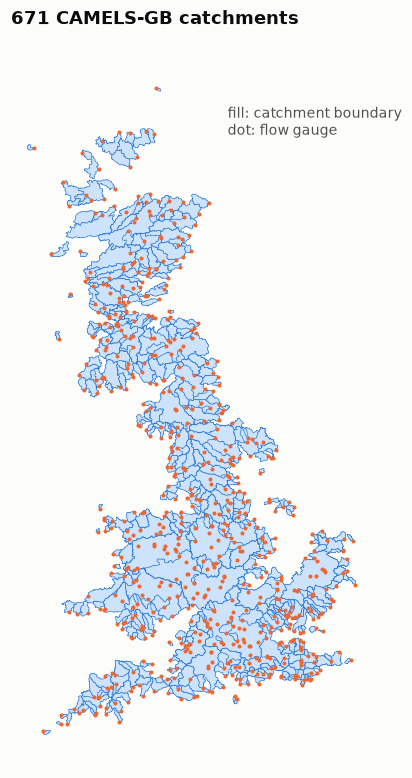

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 8.4))
catchments.plot(ax=ax, facecolor="#cde2fb", edgecolor="#2a78d6", linewidth=0.35)
ax.scatter(attrs["gauge_easting"], attrs["gauge_northing"], s=7,
           color="#eb6834", zorder=3, linewidths=0)
ax.set_title("671 CAMELS-GB catchments")
ax.text(0.60, 0.93, "fill: catchment boundary\ndot: flow gauge",
        transform=ax.transAxes, color=INK_2, fontsize=9, va="top")
ax.set_aspect("equal"); ax.set_axis_off(); ax.grid(False)
plt.show()

Coverage is national but not uniform — dense in the English lowlands and central
Scotland, sparse over the far north-west Highlands and mid-Wales.

### Two climate gradients

Rainfall and aridity are separate magnitude encodings, so each gets its **own single-hue
ramp** rather than sharing one rainbow.

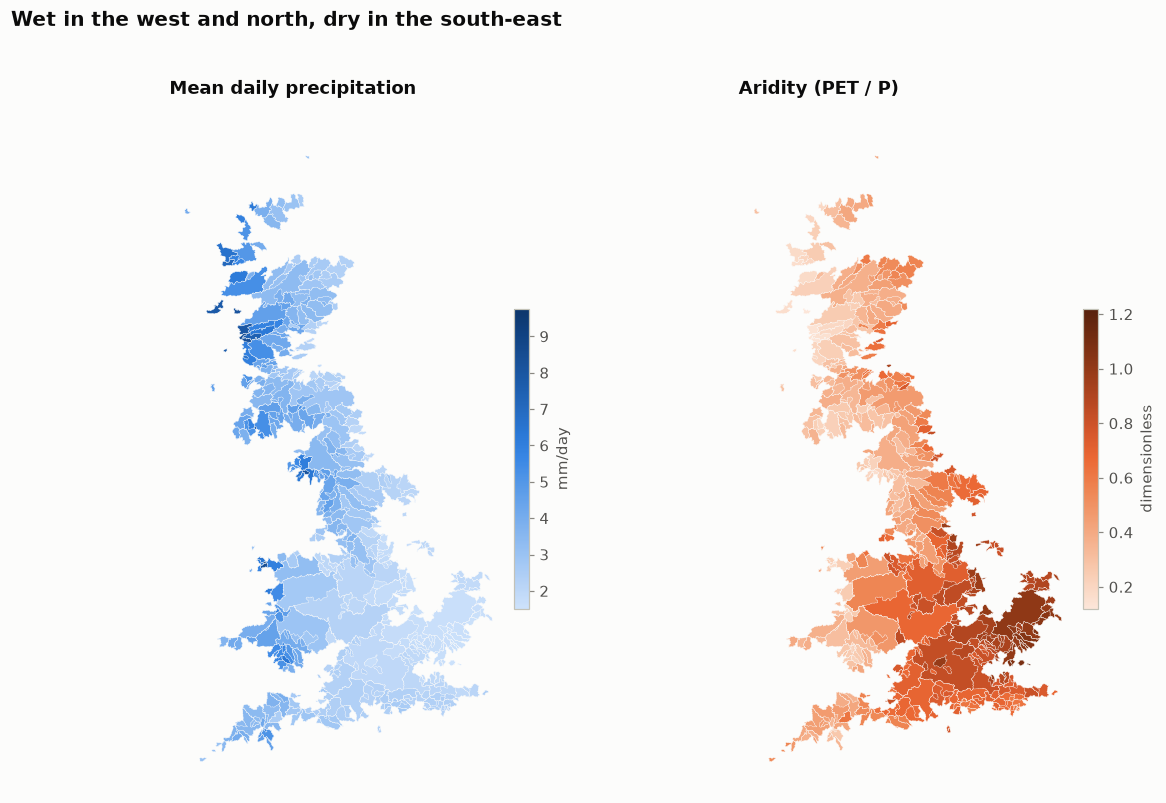

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 7.4))
panels = [
    ("p_mean",  "Mean daily precipitation", "mm/day",       SEQ_BLUE,   axes[0]),
    ("aridity", "Aridity (PET / P)",        "dimensionless", SEQ_ORANGE, axes[1]),
]
for col, title, unit, cmap, ax in panels:
    catchments.plot(column=col, ax=ax, cmap=cmap, linewidth=0.2, edgecolor=SURFACE,
                    legend=True,
                    legend_kwds={"shrink": 0.45, "label": unit, "pad": 0.01})
    ax.set_title(title)
    ax.set_aspect("equal"); ax.set_axis_off(); ax.grid(False)
fig.suptitle("Wet in the west and north, dry in the south-east",
             x=0.02, ha="left", fontsize=13, weight="bold", color=INK)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

The two maps are near mirror images: the wet uplands of western Scotland, the Lake
District and Wales sit at aridity well below 0.5, while the Thames and Anglian
catchments approach 1.0 — PET nearly equals rainfall there.

## 4. Hydrological signatures

`runoff_ratio` (Q/P) against `aridity` (PET/P) is the classic Budyko-style view of
where a catchment's water goes. Baseflow index — the fraction of flow arriving via
slow subsurface pathways — is a magnitude, so it takes the sequential blue ramp.

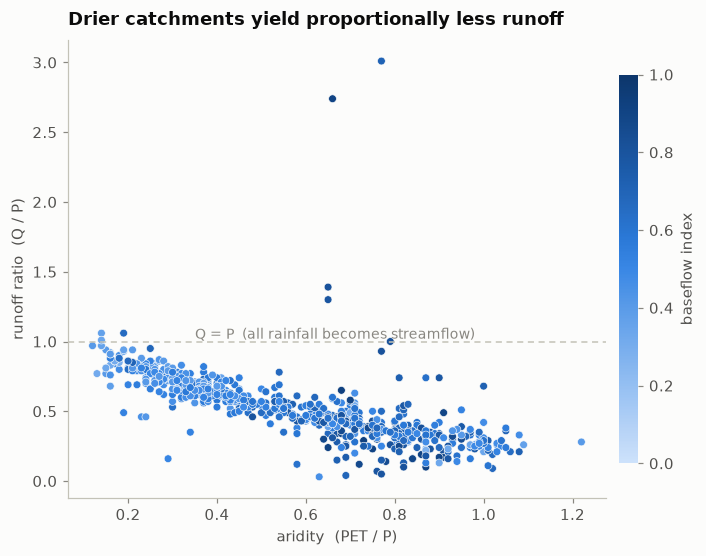

                count  mean   std   min   25%   50%   75%    max
aridity         671.0  0.56  0.25  0.12  0.35  0.56  0.77   1.22
runoff_ratio    671.0  0.53  0.24  0.03  0.36  0.53  0.69   3.01
baseflow_index  671.0  0.57  0.13  0.23  0.48  0.56  0.66   0.92
q_mean          671.0  1.93  1.58  0.09  0.74  1.41  2.63  10.32
p_mean          671.0  3.15  1.44  1.51  2.05  2.63  3.86   9.76


In [9]:
fig, ax = plt.subplots(figsize=(7.6, 5.4))
sc = ax.scatter(attrs["aridity"], attrs["runoff_ratio"],
                c=attrs["baseflow_index"], cmap=SEQ_BLUE,
                s=26, linewidths=0.4, edgecolors=SURFACE, vmin=0, vmax=1)
cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("baseflow index", color=INK_2)
cb.outline.set_visible(False)
ax.axhline(1.0, color=AXIS, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.text(0.98, 1.02, "Q = P  (all rainfall becomes streamflow)",
        color=MUTED, fontsize=9, ha="right")
ax.set_xlabel("aridity  (PET / P)")
ax.set_ylabel("runoff ratio  (Q / P)")
ax.set_title("Drier catchments yield proportionally less runoff")
ax.grid(axis="both")
plt.show()

print(attrs[["aridity", "runoff_ratio", "baseflow_index", "q_mean", "p_mean"]]
      .describe().T.round(2))

Points above the dashed line report more streamflow than rainfall — physically
impossible for a closed catchment, and a flag for either a leaky topographic
boundary (groundwater imported from a neighbouring catchment, common on Chalk)
or upstream discharges. Worth checking before using those catchments in a
water-balance model.

In [10]:
suspect = attrs.loc[attrs["runoff_ratio"] > 1,
                    ["gauge_id", "gauge_name", "area", "runoff_ratio",
                     "baseflow_index", "aridity"]].sort_values("runoff_ratio",
                                                               ascending=False)
print(f"{len(suspect)} catchments with runoff ratio > 1")
suspect.head(12)

7 catchments with runoff ratio > 1


,gauge_id,gauge_name,area,runoff_ratio,baseflow_index,aridity
126,26006,Elmswell Beck at Little Driffield,8.82,3.01,0.71,0.77
144,27038,Costa Beck at Gatehouses,8.85,2.74,0.90,0.66
400,44009,Wey at Broadwey,8.00,1.39,0.81,0.65
155,27073,Brompton Beck at Snainton Ings,8.06,1.30,0.79,0.65
53,15016,Tay at Kenmore,598.28,1.06,0.66,0.19
540,65008,Peris at Nant Peris,10.33,1.06,0.37,0.14
655,89005,Lochy at Inverlochy,47.03,1.01,0.34,0.14


## 5. Land cover change, 1990 → 2022

Eight land cover classes are given for 1990, 2015 and every year 2017–2022. The
question here is *change*, which has polarity (gain vs loss), so it takes the
**diverging** encoding — warm red for an increase, cool blue for a decrease,
neutral grey at zero. Every bar is directly labelled, so the sign never rests on
colour alone.

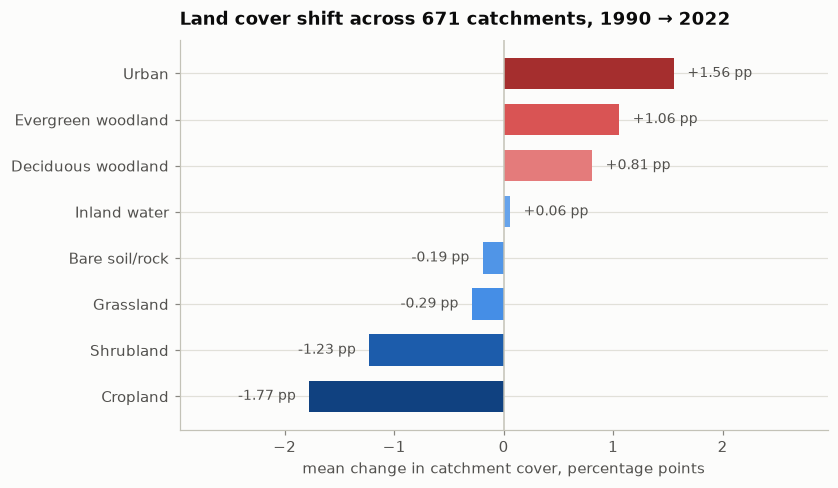

,1990,2022,change
Cropland,23.43,21.65,-1.77
Shrubland,12.02,10.79,-1.23
Grassland,45.89,45.60,-0.29
Bare soil/rock,0.58,0.39,-0.19
Inland water,0.57,0.63,0.06
Deciduous woodland,6.51,7.32,0.81
Evergreen woodland,5.13,6.19,1.06
Urban,5.86,7.42,1.56


In [11]:
CLASSES = {"dwood": "Deciduous woodland", "ewood": "Evergreen woodland",
           "grass": "Grassland", "shrub": "Shrubland", "crop": "Cropland",
           "urban": "Urban", "inwater": "Inland water", "bares": "Bare soil/rock"}

lc = pd.DataFrame({
    "1990": [attrs[f"{c}_perc_1990"].mean() for c in CLASSES],
    "2022": [attrs[f"{c}_perc_2022"].mean() for c in CLASSES],
}, index=list(CLASSES.values()))
lc["change"] = lc["2022"] - lc["1990"]
lc = lc.sort_values("change")

fig, ax = plt.subplots(figsize=(7.6, 4.6))
lim = np.abs(lc["change"]).max() * 1.15
norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
bars = ax.barh(lc.index, lc["change"],
               color=[DIVERGING(norm(v)) for v in lc["change"]], height=0.68)
for y, (name, row) in enumerate(lc.iterrows()):
    off = 0.06 * np.sign(row["change"]) * lim
    ax.text(row["change"] + off, y, f"{row['change']:+.2f} pp",
            va="center", ha="left" if row["change"] > 0 else "right",
            color=INK_2, fontsize=9)
ax.axvline(0, color=AXIS, linewidth=1)
ax.set_xlim(-lim * 1.45, lim * 1.45)
ax.set_xlabel("mean change in catchment cover, percentage points")
ax.set_title("Land cover shift across 671 catchments, 1990 → 2022")
ax.grid(axis="x"); ax.set_axisbelow(True)
plt.show()

lc.round(2)

## 6. Human influence

`benchmark_catch` marks catchments judged near-natural — the ones suitable for
detecting climate signals without unpicking abstraction and reservoir effects.

benchmark (near-natural): 137   other: 534


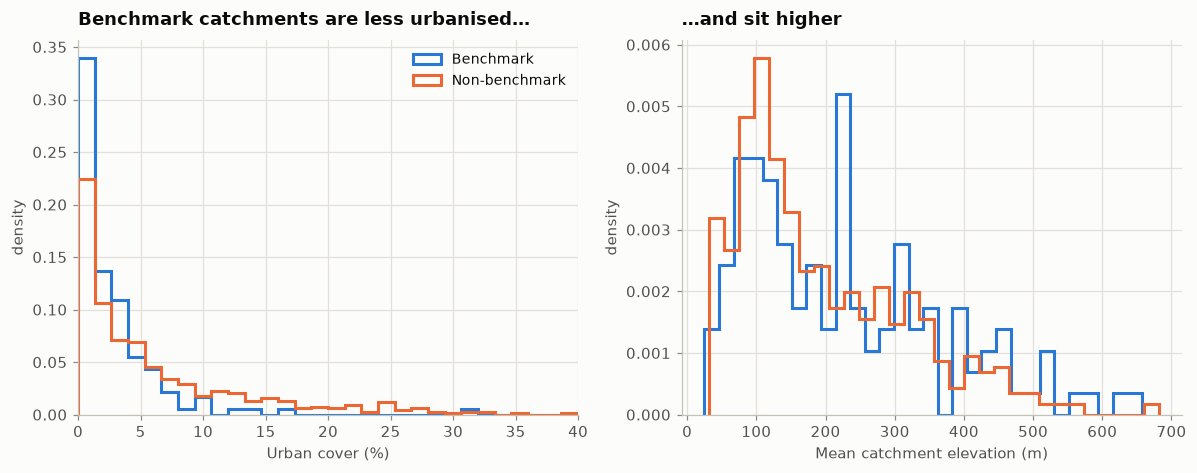

In [12]:
bench = attrs["benchmark_catch"].eq("Y")
print(f"benchmark (near-natural): {bench.sum()}   other: {(~bench).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
groups = [("Benchmark", bench, SERIES[0]), ("Non-benchmark", ~bench, SERIES[1])]

for ax, (col, label, xlim) in zip(axes, [
        ("urban_perc_2022", "Urban cover (%)", (0, 40)),
        ("elev_mean", "Mean catchment elevation (m)", None)]):
    for name, mask, colour in groups:
        ax.hist(attrs.loc[mask, col].dropna(), bins=30, range=xlim,
                histtype="step", linewidth=2, color=colour, label=name, density=True)
    ax.set_xlabel(label); ax.set_ylabel("density")
    if xlim: ax.set_xlim(*xlim)
axes[0].set_title("Benchmark catchments are less urbanised…")
axes[1].set_title("…and sit higher")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Daily time series — one catchment end to end

Every daily file covers the same span, 1970-10-01 → 2022-09-30 (18,993 days), with
eleven columns: two precipitation products, four PET/PETI products, two temperature
products, and discharge as both specific (mm/day) and volumetric (m³/s).

In [13]:
def gauge_file(folder, gauge_id):
    hits = sorted(folder.glob(f"*_{gauge_id}_*.csv"))
    if not hits:
        raise FileNotFoundError(f"no file for gauge {gauge_id} in {folder.name}")
    return hits[0]

def read_daily(gauge_id, usecols=None):
    df = pd.read_csv(gauge_file(DAILY, gauge_id), parse_dates=["date"],
                     usecols=usecols, na_values=["NaN"])
    return df.set_index("date")

GAUGE = 39001  # Thames at Kingston -- the largest gauged catchment in the set
meta = attrs.loc[attrs["gauge_id"] == GAUGE].iloc[0]
print(f"{GAUGE}  {meta['gauge_name']}   area {meta['area']:,.0f} km2   "
      f"BFI {meta['baseflow_index']:.2f}   record {meta['daily_flow_perc_complete']:.1f}% complete")

one = read_daily(GAUGE)
print(one.shape, "|", one.index.min().date(), "->", one.index.max().date())
one.head()

39001  Thames at Kingston   area 9,931 km2   BFI 0.63   record 100.0% complete
(18993, 10) | 1970-10-01 -> 2022-09-30


,precipitation_cehgear,precipitation_haduk,pet_chess,peti_chess,pet_hydrope,peti_hydrope,temperature_chess,temperature_haduk,discharge_spec,discharge_vol
date,,,,,,,,,,
1970-10-01,0.02,0.02,1.74,1.75,1.97,1.98,12.92,14.20,0.09,10.10
1970-10-02,0.52,0.52,3.02,3.17,1.04,1.22,13.28,11.10,0.09,10.30
1970-10-03,0.05,0.05,2.28,2.30,1.36,1.38,11.31,12.11,0.08,9.10
1970-10-04,0.05,0.05,0.41,0.42,2.38,2.39,13.54,15.39,0.08,9.19
1970-10-05,3.85,3.93,1.31,1.54,1.05,1.38,14.37,11.00,0.09,10.50


A hydrograph is two measures on different scales. That is **two panels sharing an
x-axis**, never one panel with two y-axes — a dual axis lets the author place the
crossings anywhere they like, so the apparent lead/lag is an artefact of the scaling.

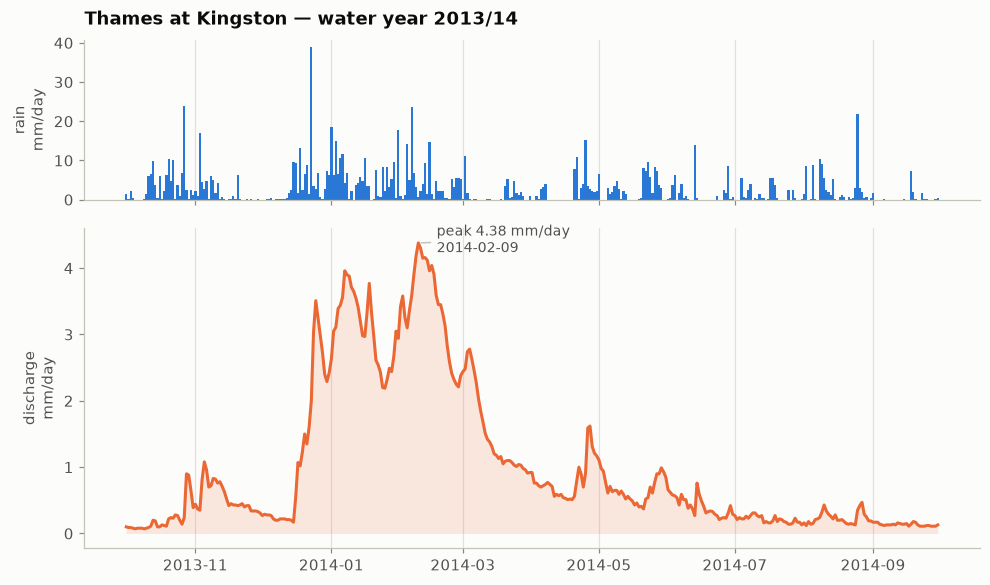

In [14]:
window = slice("2013-10-01", "2014-09-30")   # the winter 2013/14 floods
sub = one.loc[window]

fig, (ax_p, ax_q) = plt.subplots(2, 1, figsize=(10.5, 6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 2], "hspace": 0.12})

ax_p.bar(sub.index, sub["precipitation_cehgear"], width=1.0,
         color=SERIES[0], linewidth=0)
ax_p.set_ylabel("rain\nmm/day")
ax_p.set_title(f"{meta['gauge_name']} — water year 2013/14")
ax_p.grid(axis="y")

ax_q.plot(sub.index, sub["discharge_spec"], color=SERIES[1])
ax_q.fill_between(sub.index, sub["discharge_spec"], color=SERIES[1], alpha=0.14,
                  linewidth=0)
ax_q.set_ylabel("discharge\nmm/day")
ax_q.grid(axis="y")

peak = sub["discharge_spec"].idxmax()
ax_q.annotate(f"peak {sub['discharge_spec'].max():.2f} mm/day\n{peak.date()}",
              xy=(peak, sub["discharge_spec"].max()),
              xytext=(12, -6), textcoords="offset points",
              color=INK_2, fontsize=9,
              arrowprops=dict(arrowstyle="-", color=AXIS, linewidth=1))
plt.show()

### Do the two precipitation products agree?

CEH-GEAR and HadUK-Grid are independent griddings of the same rain gauge network.
Plotting both as lines would be a mistake here — they agree so closely that one
series simply hides under the other, and the reader cannot tell that two were
drawn. The honest form for "do two measurements agree" is the **paired
comparison**: each day as one point against the 1:1 line, plus the distribution
of the difference. 19,000 points overplot, so density carries magnitude on the
sequential blue ramp.

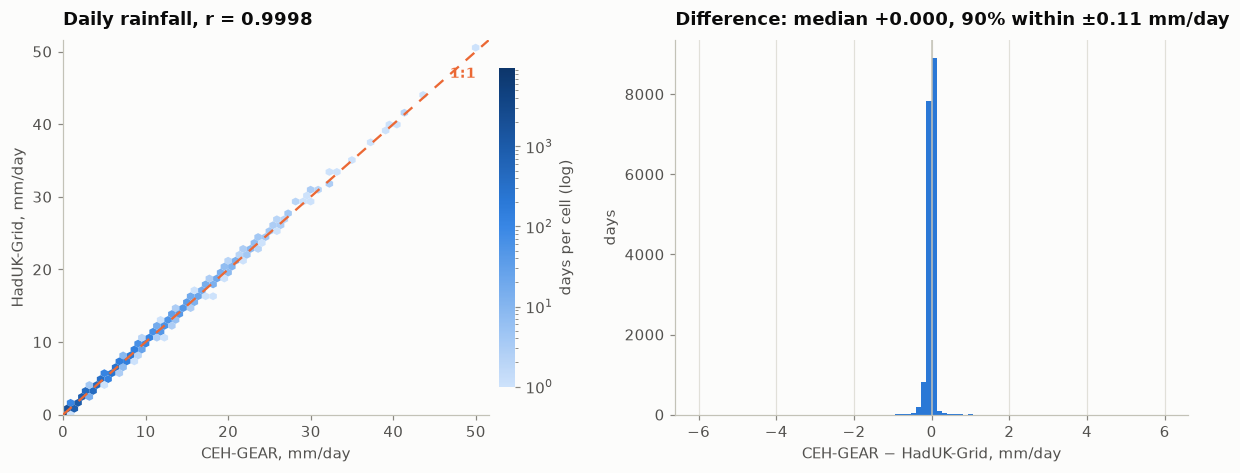

days where the two products differ by more than 1 mm: 5 of 17,989 (0.0%)


In [15]:
pair = one[["precipitation_cehgear", "precipitation_haduk"]].dropna()
diff = pair["precipitation_cehgear"] - pair["precipitation_haduk"]
r = pair.corr().iloc[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

hb = ax1.hexbin(pair["precipitation_cehgear"], pair["precipitation_haduk"],
                gridsize=55, bins="log", cmap=SEQ_BLUE, mincnt=1, linewidths=0)
lim = float(pair.to_numpy().max()) * 1.02
ax1.plot([0, lim], [0, lim], color=SERIES[1], linewidth=1.5,
         linestyle=(0, (5, 4)), zorder=3)
ax1.text(lim * 0.97, lim * 0.90, "1:1", color=SERIES[1], fontsize=9,
         ha="right", weight="bold")
cb = fig.colorbar(hb, ax=ax1, shrink=0.85, pad=0.02)
cb.set_label("days per cell (log)", color=INK_2); cb.outline.set_visible(False)
ax1.set_xlim(0, lim); ax1.set_ylim(0, lim)
ax1.set_xlabel("CEH-GEAR, mm/day"); ax1.set_ylabel("HadUK-Grid, mm/day")
ax1.set_title(f"Daily rainfall, r = {r:.4f}")
ax1.grid(axis="both")

ax2.hist(diff, bins=90, range=(-6, 6), color=SERIES[0], linewidth=0)
ax2.axvline(0, color=AXIS, linewidth=1)
ax2.set_xlabel("CEH-GEAR − HadUK-Grid, mm/day"); ax2.set_ylabel("days")
ax2.set_title(f"Difference: median {diff.median():+.3f}, "
              f"90% within ±{diff.abs().quantile(0.90):.2f} mm/day")
ax2.grid(axis="y")
plt.tight_layout()
plt.show()

print(f"days where the two products differ by more than 1 mm: "
      f"{int((diff.abs() > 1).sum()):,} of {len(diff):,} "
      f"({(diff.abs() > 1).mean() * 100:.1f}%)")

## 8. Record completeness across all 671 catchments

The meteorology is a gridded reanalysis and so is complete everywhere; **discharge
is the gappy variable**. The hydrometry table reports completeness directly.

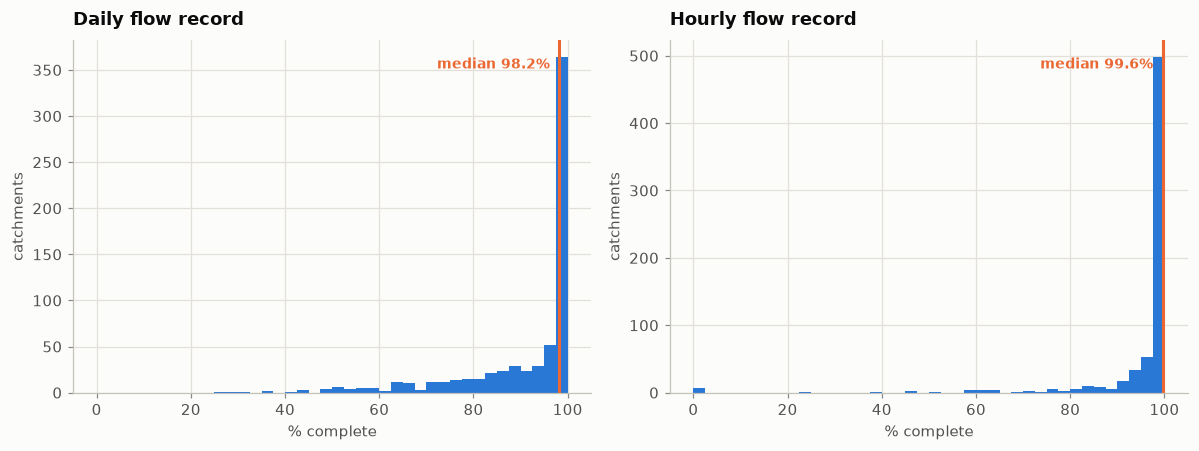

                           count  mean   std   min   25%   50%    75%    max
daily_flow_perc_complete   671.0  91.2  13.6  26.9  86.9  98.2  100.0  100.0
hourly_flow_perc_complete  671.0  95.5  13.0   0.0  97.2  99.6  100.0  100.0

catchments with a >=95% complete daily record: 416


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (col, title) in zip(axes, [
        ("daily_flow_perc_complete", "Daily flow record"),
        ("hourly_flow_perc_complete", "Hourly flow record")]):
    ax.hist(attrs[col].dropna(), bins=40, range=(0, 100), color=SERIES[0], linewidth=0)
    med = attrs[col].median()
    ax.axvline(med, color=SERIES[1], linewidth=2)
    ax.text(med - 2, ax.get_ylim()[1] * 0.92, f"median {med:.1f}%",
            color=SERIES[1], ha="right", fontsize=9, weight="bold")
    ax.set_xlabel("% complete"); ax.set_ylabel("catchments"); ax.set_title(title)
plt.tight_layout()
plt.show()

print((attrs[["daily_flow_perc_complete", "hourly_flow_perc_complete"]]
       .describe().T.round(1)))
print("\ncatchments with a >=95% complete daily record:",
      int((attrs["daily_flow_perc_complete"] >= 95).sum()))

### The real scan — every daily discharge series

671 files, ~19k rows each. Reading only `date` and `discharge_spec` keeps this to a
few tens of seconds; the result is cached as Parquet so later runs are instant.

In [17]:
Q_CACHE = CACHE / "daily_discharge_spec.parquet"

if Q_CACHE.exists():
    Q = pd.read_parquet(Q_CACHE)
    print(f"loaded cache: {Q_CACHE.relative_to(ROOT)}")
else:
    t0 = time.time()
    series = {}
    for i, f in enumerate(sorted(DAILY.glob("*.csv"))):
        gid = int(f.stem.split("_")[-2])
        d = pd.read_csv(f, usecols=["date", "discharge_spec"],
                        parse_dates=["date"], na_values=["NaN"])
        series[gid] = d.set_index("date")["discharge_spec"].astype("float32")
        if (i + 1) % 200 == 0:
            print(f"  {i+1}/671  ({time.time()-t0:.0f}s)")
    Q = pd.DataFrame(series).sort_index(axis=1)
    Q.to_parquet(Q_CACHE)
    print(f"read 671 files in {time.time()-t0:.0f}s -> cached")

print(f"{Q.shape[0]:,} days x {Q.shape[1]} catchments   "
      f"({Q.notna().to_numpy().mean()*100:.1f}% of cells observed)")
Q.iloc[:3, :6]

loaded cache: cache/daily_discharge_spec.parquet
18,993 days x 671 catchments   (91.2% of cells observed)


,1001,2001,2002,3003,4001,4003
date,,,,,,
1970-10-01,NaN,NaN,NaN,NaN,NaN,NaN
1970-10-02,NaN,NaN,NaN,NaN,NaN,NaN
1970-10-03,NaN,NaN,NaN,NaN,NaN,NaN


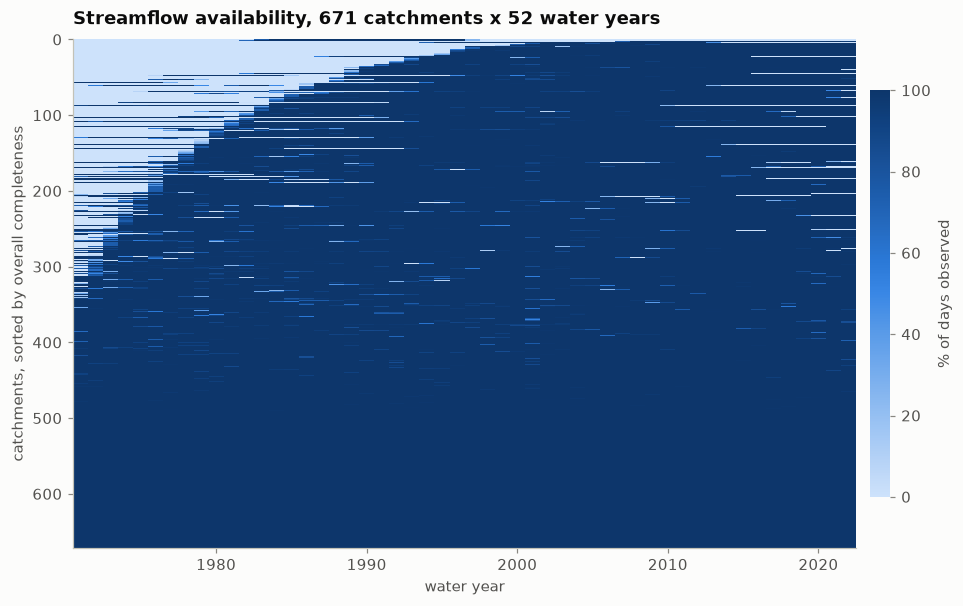

The record thickens through the 1970s-80s as gauges come online; 
best-covered water year has 658 catchments at 100% completeness.


In [18]:
# Availability by water year (UK water year starts 1 October).
wy = Q.index.year + (Q.index.month >= 10).astype(int)
avail = Q.notna().groupby(wy).mean().T * 100
order = avail.mean(axis=1).sort_values().index
avail = avail.loc[order]

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(avail.values, aspect="auto", cmap=SEQ_BLUE, vmin=0, vmax=100,
               interpolation="nearest",
               extent=(avail.columns.min() - 0.5, avail.columns.max() + 0.5,
                       len(avail), 0))
cb = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.015)
cb.set_label("% of days observed", color=INK_2); cb.outline.set_visible(False)
ax.set_xlabel("water year"); ax.set_ylabel("catchments, sorted by overall completeness")
ax.set_title(f"Streamflow availability, {avail.shape[0]} catchments "
             f"x {avail.shape[1]} water years")
ax.grid(False)
plt.show()

n_full = int((Q.notna().groupby(wy).mean() == 1).sum(axis=1).max())
print("The record thickens through the 1970s-80s as gauges come online;",
      f"\nbest-covered water year has {n_full} catchments at 100% completeness.")

## 9. Flood-relevant extremes

For flood work the quantity of interest is the **annual maximum** (AMAX) series —
the largest daily mean flow in each water year — plus *when* in the year it lands.

AMAX values: 31,064 catchment-years from a possible 34,892


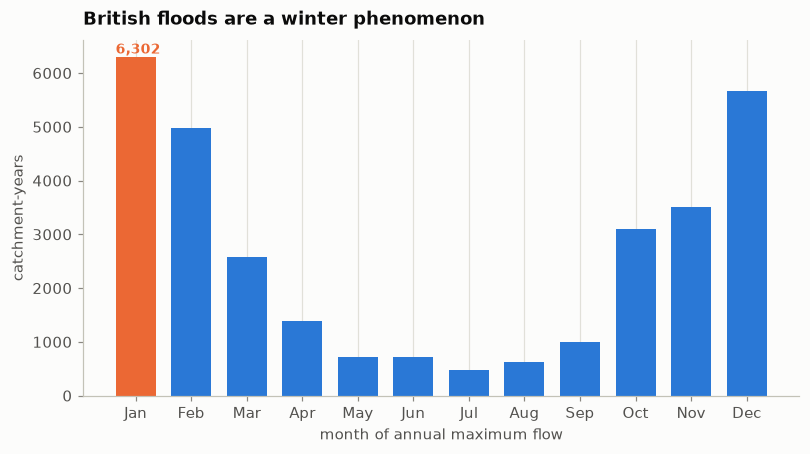

55% of annual maxima fall in December-February.


In [19]:
q_by_wy = Q.groupby(wy)
counts = q_by_wy.count()
amax = q_by_wy.max().where(counts >= 350)     # drop water years that are too gappy
def month_of_max(g):
    # DataFrame.idxmax raises on an all-NaN column, so go column by column.
    return g.apply(lambda s: s.idxmax().month if s.notna().any() else np.nan)

amax_month = Q.groupby(wy).apply(month_of_max).where(counts >= 350)

print(f"AMAX values: {int(amax.notna().to_numpy().sum()):,} "
      f"catchment-years from a possible {amax.size:,}")

month_counts = (amax_month.stack().dropna().astype(int)
                .value_counts().reindex(range(1, 13), fill_value=0))
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(8.4, 4.2))
bars = ax.bar(MONTHS, month_counts.values, color=SERIES[0], linewidth=0, width=0.72)
top = month_counts.idxmax()
bars[top - 1].set_color(SERIES[1])
ax.text(top - 1, month_counts.max(), f" {month_counts.max():,}", ha="center",
        va="bottom", color=SERIES[1], fontsize=9, weight="bold")
ax.set_ylabel("catchment-years"); ax.set_xlabel("month of annual maximum flow")
ax.set_title("British floods are a winter phenomenon")
ax.grid(axis="y")
plt.show()

winter = month_counts[[12, 1, 2]].sum() / month_counts.sum() * 100
print(f"{winter:.0f}% of annual maxima fall in December-February.")

### How extreme is extreme?

Ratio of the largest recorded annual maximum to the *median* annual maximum — how
far the worst year stands above a typical one. Note what this is not: it is a
**relative** index, so a placid catchment that floods once in fifty years scores
higher than a big river that floods most winters.

The tempting story — "small, steep, impermeable catchments are flashiest" — is not
what this data says. Every correlation below is weak, and baseflow index is
essentially uncorrelated (ρ = +0.09); colouring by it would imply a pattern that
is not there. Aridity and rainfall lead a weak field.

p_mean           -0.231
aridity           0.217
area             -0.190
dpsbar           -0.178
elev_mean        -0.169
baseflow_index    0.089


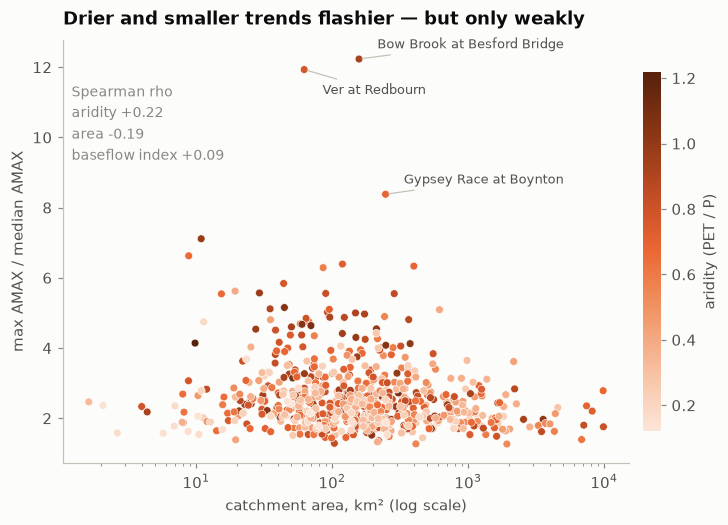

,gauge_name,area,aridity,baseflow_index,amax_ratio
gauge_id,,,,,
54015,Bow Brook at Besford Bridge,158.31,0.93,0.43,12.23
39125,Ver at Redbourn,62.58,0.77,0.79,11.93
26005,Gypsey Race at Boynton,248.13,0.69,0.69,8.38


In [20]:
ratio = (amax.max() / amax.median()).rename("amax_ratio")
sev = attrs.set_index("gauge_id").join(ratio, how="inner").dropna(subset=["amax_ratio"])

drivers = ["aridity", "p_mean", "area", "dpsbar", "elev_mean", "baseflow_index"]
rho = pd.Series(
    {c: sev[["amax_ratio", c]].dropna().corr(method="spearman").iloc[0, 1]
     for c in drivers}, name="Spearman rho").sort_values(key=abs, ascending=False)
print(rho.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(sev["area"], sev["amax_ratio"], c=sev["aridity"],
                cmap=SEQ_ORANGE, s=26, linewidths=0.4, edgecolors=SURFACE)
cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("aridity (PET / P)", color=INK_2); cb.outline.set_visible(False)
ax.set_xscale("log")
ax.set_xlabel("catchment area, km² (log scale)")
ax.set_ylabel("max AMAX / median AMAX")
ax.set_title("Drier and smaller trends flashier — but only weakly")
ax.text(0.015, 0.90,
        f"Spearman rho\naridity {rho['aridity']:+.2f}\narea {rho['area']:+.2f}\n"
        f"baseflow index {rho['baseflow_index']:+.2f}",
        transform=ax.transAxes, ha="left", va="top", color=MUTED, fontsize=9,
        linespacing=1.5)
ax.grid(axis="both")

# Label the outliers, offsetting alternately so the callouts do not collide.
worst = sev["amax_ratio"].nlargest(3)
for k, (gid, val) in enumerate(worst.items()):
    ax.annotate(sev.loc[gid, "gauge_name"], xy=(sev.loc[gid, "area"], val),
                xytext=(12, -16 if k == 1 else 7), textcoords="offset points",
                fontsize=8.5, color=INK_2,
                arrowprops=dict(arrowstyle="-", color=AXIS, linewidth=0.8))
plt.show()

sev.loc[worst.index, ["gauge_name", "area", "aridity", "baseflow_index",
                      "amax_ratio"]].round(2)

## 10. Hourly data — what the daily series hides

The hourly files are the reason this dataset is 10 GiB. Each holds 280,512 hourly
steps from 1990-10-01 09:00 to 2022-10-01 08:00, with rainfall, discharge, level,
and quality flags.

> **Unit trap.** `discharge_spec` does **not** carry the same units in the two
> folders: it is **mm/day** in the daily files and **mm/hour** in the hourly ones.
> The column name is identical and nothing in the CSVs announces the change, so
> comparing the two directly is silently wrong by a factor of 24. `discharge_vol`
> (m³/s) *is* the same in both. It is documented — in the publisher's supporting
> information, not in the files (see notebook 02) — but nothing warns you at read
> time, so the next cell demonstrates it rather than taking it on trust.

In [21]:
def read_hourly(gauge_id, usecols=None):
    return pd.read_csv(gauge_file(HOURLY, gauge_id), parse_dates=["date"],
                       usecols=usecols, na_values=["NaN"]).set_index("date")

FLASHY = 54008  # Teme at Tenbury -- responsive, and ~100% complete at both steps
h = read_hourly(FLASHY, usecols=["date", "precipitation_cehgear",
                                 "discharge_spec", "discharge_vol", "level"])
d = read_daily(FLASHY, usecols=["date", "discharge_spec", "discharge_vol"])
print(f"{h.shape[0]:,} hourly steps | columns: {list(h.columns)}")
print(h.notna().mean().round(3).to_string())

# The hourly record is stamped 09:00 -> 09:00, so aggregate on that offset.
h_as_daily = h.resample("24h", offset="9h").mean()
h_as_daily.index = h_as_daily.index.normalize()
paired = h_as_daily.join(d, lsuffix="_hourly", rsuffix="_daily").dropna()

print(f"\n{len(paired):,} days where both files carry data")
for col in ["discharge_spec", "discharge_vol"]:
    r = (paired[f"{col}_hourly"] / paired[f"{col}_daily"]).median()
    print(f"  {col:15s} hourly-mean / daily = {r:.4f}    (1/24 = {1/24:.4f})")

280,512 hourly steps | columns: ['precipitation_cehgear', 'discharge_spec', 'discharge_vol', 'level']
precipitation_cehgear    0.82
discharge_spec           1.00
discharge_vol            1.00
level                    1.00

9,589 days where both files carry data
  discharge_spec  hourly-mean / daily = 0.0417    (1/24 = 0.0417)
  discharge_vol   hourly-mean / daily = 1.0012    (1/24 = 0.0417)


`discharge_spec` comes out at 1/24 to four decimal places while `discharge_vol`
sits at 1.00 — that is the proof, not a guess. Scaling the hourly specific
discharge by 24 puts both series on one honest axis, and the reason the hourly
files exist becomes visible: **the daily mean clips the peak**, and how much it
clips depends on catchment size.

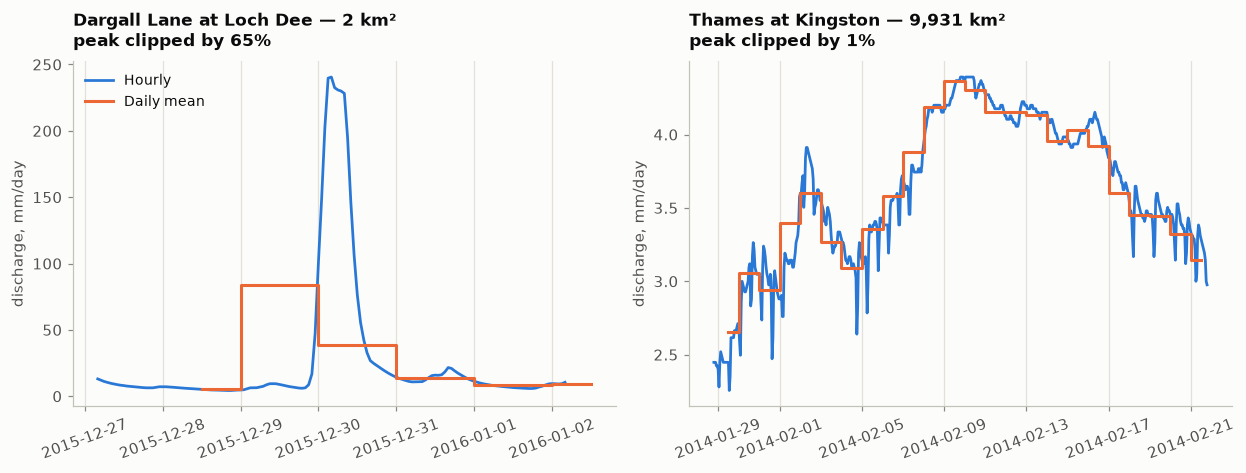

In [22]:
def hourly_mm_per_day(gauge_id):
    s = read_hourly(gauge_id, usecols=["date", "discharge_spec"])["discharge_spec"]
    return s * 24                                     # mm/hour -> mm/day

def daily_from_hourly(s):
    out = s.resample("24h", offset="9h").mean()       # 09:00 -> 09:00, as published
    out.index = out.index.normalize()
    return out

# One small flashy catchment against one large slow one, same treatment.
PAIR = [(80005, "3D"), (39001, "12D")]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

for ax, (gid, half) in zip(axes, PAIR):
    hq = hourly_mm_per_day(gid)
    dq = daily_from_hourly(hq)
    pk = hq.idxmax()
    win = slice(pk - pd.Timedelta(half), pk + pd.Timedelta(half))
    hw, dw = hq.loc[win], dq.loc[win]
    clip = (1 - dw.max() / hw.max()) * 100
    row = attrs.loc[attrs["gauge_id"] == gid].iloc[0]

    ax.plot(hw.index, hw.values, color=SERIES[0], linewidth=1.8, label="Hourly")
    ax.step(dw.index + pd.Timedelta("12h"), dw.values, where="mid",
            color=SERIES[1], linewidth=2, label="Daily mean")
    ax.set_title(f"{row['gauge_name']} — {row['area']:,.0f} km²\n"
                 f"peak clipped by {clip:.0f}%", fontsize=11)
    ax.set_ylabel("discharge, mm/day")
    ax.tick_params(axis="x", labelrotation=20)
    ax.grid(axis="y")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

One pair of events is an anecdote. To generalise, take a **stratified sample of 14
catchments spanning the full area range** (restricted to those with a >98% complete
hourly record) and measure the clipping at each one's largest event. This reads 14
hourly files — about a minute — and is cached.

*This is a sample, not the full 671: a complete sweep would read all 9.9 GiB. The
relationship below is strong enough to be worth confirming at full scale before
being relied on.*

In [23]:
CLIP_CACHE = CACHE / "hourly_peak_clipping.parquet"

if CLIP_CACHE.exists():
    clip_df = pd.read_parquet(CLIP_CACHE)
    print(f"loaded cache: {CLIP_CACHE.relative_to(ROOT)}")
else:
    pool = (attrs[attrs["hourly_flow_perc_complete"] > 98]
            .sort_values("area").reset_index(drop=True))
    picks = pool.iloc[np.linspace(0, len(pool) - 1, 14).astype(int)]
    print(f"sampling 14 of {len(pool)} catchments with >98% hourly completeness")

    recs = []
    t0 = time.time()
    for _, r in picks.iterrows():
        hq = hourly_mm_per_day(int(r["gauge_id"]))
        dq = daily_from_hourly(hq)
        recs.append({"gauge_id": int(r["gauge_id"]), "gauge_name": r["gauge_name"],
                     "area": r["area"], "hourly_peak": hq.max(),
                     "daily_peak": dq.max(),
                     "clip_pct": (1 - dq.max() / hq.max()) * 100})
    clip_df = pd.DataFrame(recs)
    clip_df.to_parquet(CLIP_CACHE)
    print(f"read 14 hourly files in {time.time() - t0:.0f}s -> cached")

clip_df.sort_values("area").round(2)

loaded cache: cache/hourly_peak_clipping.parquet


,gauge_id,gauge_name,area,hourly_peak,daily_peak,clip_pct
0,80005,Dargall Lane at Loch Dee,2.07,240.55,94.38,60.77
1,84026,Allander Water at Milngavie,30.65,179.40,124.45,30.63
2,28055,Ecclesbourne at Duffield,51.06,61.25,27.12,55.72
3,65001,Glaslyn at Beddgelert,66.96,346.37,138.10,60.13
4,41006,Uck at Isfield,89.16,128.02,61.64,51.85
5,21023,Leet Water at Coldstream,112.95,59.95,46.68,22.14
6,34007,Dove at Oakley Park,139.37,24.22,22.67,6.38
7,38030,Beane at Hartham,173.85,15.12,9.45,37.51
8,78006,Annan at Woodfoot,218.02,74.81,65.75,12.11
9,72002,Wyre at St Michaels,273.75,56.54,51.64,8.68


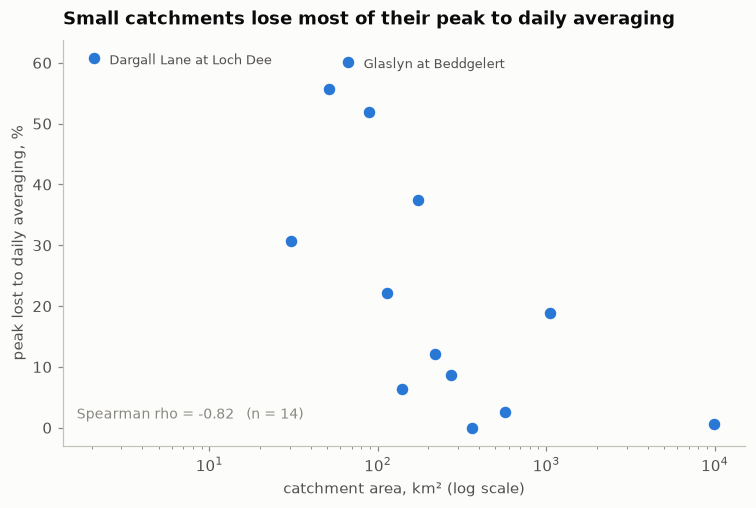

In [24]:
rho_clip = clip_df[["clip_pct", "area"]].corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(clip_df["area"], clip_df["clip_pct"], s=70, color=SERIES[0],
           edgecolors=SURFACE, linewidths=0.8, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("catchment area, km² (log scale)")
ax.set_ylabel("peak lost to daily averaging, %")
ax.set_title("Small catchments lose most of their peak to daily averaging")
ax.text(0.02, 0.06, f"Spearman rho = {rho_clip:+.2f}   (n = {len(clip_df)})",
        transform=ax.transAxes, ha="left", va="bottom", color=MUTED, fontsize=9)

for _, r in clip_df.nlargest(2, "clip_pct").iterrows():
    ax.annotate(r["gauge_name"], xy=(r["area"], r["clip_pct"]),
                xytext=(10, -4), textcoords="offset points",
                fontsize=8.5, color=INK_2)
ax.grid(axis="both")
plt.show()

This is the whole argument for the hourly files. On a 2 km² headwater the daily
mean throws away roughly **60% of the peak**; on the Thames at Kingston it costs
under 1%. Flood frequency analysis is fitted to peak magnitude, so for small
catchments the daily series is not a cheaper version of the hourly one — it is a
different and much smaller number.

## 11. Groundwater

55 wells, each with a monthly level series; 23 of them also have daily. The wells
are not co-located with the flow gauges — they are a separate network.

In [25]:
def read_gw(freq, well_id):
    hits = sorted((GW / freq).glob(f"*_{well_id.lower()}_*.csv"))
    return (pd.read_csv(hits[0], parse_dates=["date"], na_values=["NaN"])
            .set_index("date")["groundwater_level"]) if hits else None

print(wells[["gw_well_id", "gw_well_name", "aquifer", "gw_well_depth",
             "monthly_gwlevel_perc_complete"]].head(8).to_string(index=False))
print("\naquifers:")
print(wells["aquifer"].value_counts().to_string())

gw_well_id                         gw_well_name                  aquifer  gw_well_depth  monthly_gwlevel_perc_complete
    NY62_4 ESPLAND HILL (NR. BRAMPTON- APPLEBY) Permo-Triassic sandstone          101.6                          39.65
   SD53_25                        RED SCAR WOOD Permo-Triassic sandstone           38.1                          94.54
   SE02_46                           THRUM HALL           Millstone Grit           62.0                          89.02
    SE23_4               SILVER BLADES ICE RINK            Coal Measures           45.7                          87.33
   SE28_28                               BEDALE      Magnesian limestone           19.2                          91.35
    SE35_4                          CASTLE FARM      Magnesian limestone           53.3                          89.47
   SE36_47                         KELLY'S CAFE Permo-Triassic sandstone           74.6                          91.98
  SE39_20B                      SCRUTON VILLAGE 

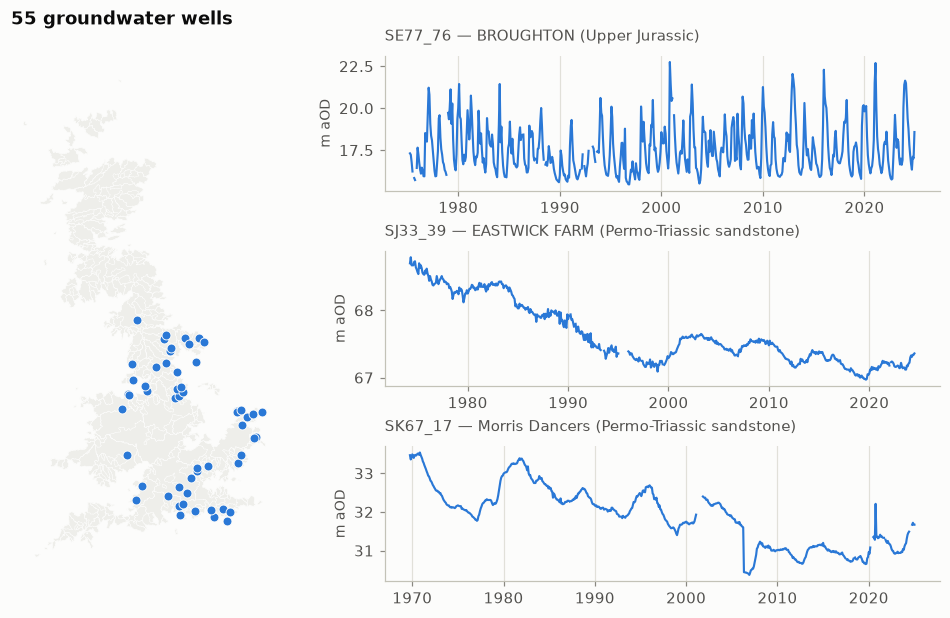

In [26]:
fig = plt.figure(figsize=(11.5, 6.2))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1.5], hspace=0.45, wspace=0.12)

ax_map = fig.add_subplot(gs[:, 0])
catchments.plot(ax=ax_map, facecolor="#eeeeea", edgecolor=SURFACE, linewidth=0.3)
ax_map.scatter(wells["gw_well_easting"], wells["gw_well_northing"],
               s=34, color=SERIES[0], edgecolors=SURFACE, linewidths=0.6, zorder=3)
ax_map.set_title("55 groundwater wells")
ax_map.set_aspect("equal"); ax_map.set_axis_off(); ax_map.grid(False)

# Three wells, one per panel -- small multiples, so no colour is asked to
# distinguish series that share an axis.
picks = (wells.sort_values("monthly_gwlevel_perc_complete", ascending=False)
              .head(3))
for i, (_, w) in enumerate(picks.iterrows()):
    ax = fig.add_subplot(gs[i, 1])
    s = read_gw("monthly", w["gw_well_id"])
    ax.plot(s.index, s.values, color=SERIES[0], linewidth=1.4)
    ax.set_title(f"{w['gw_well_id']} — {w['gw_well_name']} ({w['aquifer']})",
                 fontsize=10, weight="normal", color=INK_2)
    ax.set_ylabel("m aOD", fontsize=9)
    ax.grid(axis="y")
plt.show()

## 12. Summary

| | |
|---|---|
| Catchments | 671, national coverage, 1.6 – 9,931 km² |
| Static attributes | 8 tables, ~230 columns per catchment |
| Daily record | 18,993 days × 671 = 12.7 M catchment-days |
| Hourly record | 280,512 steps × 671 |
| Groundwater | 55 wells (monthly), 23 also daily |
| Near-natural benchmark set | 137 catchments |

**Watch-outs for downstream work**

1. Meteorology is complete everywhere; **discharge is the gap**. Filter on
   `daily_flow_perc_complete` before any whole-record statistic.
2. Early water years are thin — the gauge network fills out through the 1970s–80s.
   The availability heatmap shows where a common period should start.
3. Runoff ratio > 1 flags catchments whose topographic boundary does not match
   their groundwater catchment. Exclude them from water-balance work.
4. Daily means clip flood peaks — use the hourly files for peak magnitude, and
   mind that **`discharge_spec` is mm/day in the daily files but mm/hour in the
   hourly ones**. `discharge_vol` (m³/s) is consistent across both.
5. Two precipitation and four PET products are supplied — pick one and be
   consistent, they are not interchangeable.

**Next steps worth taking**

- Build an AMAX/POT table and fit flood frequency curves (GEV/GLO) per catchment.
- Cluster catchments on the attribute space and check whether the clusters
  predict flood response — the pairwise correlations above are far too weak to be
  useful on their own.
- Assemble a modelling matrix (attributes + lagged rainfall) for rainfall-runoff
  or peak-prediction models.